# MINST Example
detecting 3 and 7

## Note
We are learning about Binary and regression classification techniques. In deep learning there are other classification tasks like multi-class classification, where we have more than two classes to predict. 

the core of the fundamentals are:

data (batched) 
  → model.forward(x) [forward pass] 
  → loss = criterion(preds, targets) [differentiable scalar] 
  → loss.backward() [chain rule → fills .grad for each param] 
  → optimizer.step() [updates weights using lr & gradients] 
  → optimizer.zero_grad() [clears .grad for next step] 
  → repeat until convergence / validation stops improvement


the core of the the backwards pass is the same (use derivatives and step to update the weights)

loss function is always loss_fn(predictions, targets) but the maths inside is different for each classification task.

What Stays Constant

preds → continuous model output	Always a differentiable tensor

targets → ground truth labels	Fixed reference values

Output → single scalar loss	Must be one number per batch for .backward()

Aggregation → .mean() (or .sum())	Converts per-sample errors into one optimization signal

Differentiability → gradients flow back	Non-negotiable for SGD/Adam

### My Definition of UAT 
Understanding UAT: A grayscale image (e.g., 28×28 pixels, values 0–255) can be flattened into a high-dimensional vector. A purely linear model draws a flat decision boundary that splits the space into two regions (predicting one class or the other). But real-world data like handwritten digits isn't linearly separable—the patterns are scattered and complex. By adding ReLU, we introduce piecewise bends (sharp kinks) that let the boundary fold and curve around data clusters. The goal isn't to find a single straight line, but to learn optimal weights that define a flexible decision boundary capturing the underlying pattern. The loss function quantifies how wrong our predictions are, and its gradient points uphill toward higher error. Since we want to minimize loss, we step in the opposite direction, update our weights, and repeat until the model generalizes well.

### Loss functions and metrics
A metric is a measure of how well the model is performing, Metrics are usually averages or task-specific calculations.
A loss is a function that measures how far off the prediction is from the target, it is the compass that tells us which way to navigate to reduce loss. It is essential in automated learning and requires a meaningful derivative. 
A meaning ful derivative requires a smooth graph where there are no major peaks and valleys, and where the slope changes gradually, so the loss function must be something that can provide this.


### Prediction is just your data x random values via matrix multiplication then get the gradiant to update the matrix to get better results
Predict: data × initial random weights (via matrix multiplication) → raw guesses
Measure error: Compare predictions to the true labels (yb) using a loss function
Find direction: Use gradients (derivatives) to figure out how each weight should change
Update: Nudge the weights slightly in that direction
Repeat: Do this thousands of times across many batches until the random values become highly tuned patterns


### Bias role with weights
predictions => pred = (weights @ input) + bias

Think of it like a sliding door:

weights = how steeply the door opens/closes based on input
bias = where you set the door's starting position so it actually aligns with the frame (your data)

If your data naturally clusters around y=0.6 instead of y=0, bias learns to shift the line up so predictions land in that region, and the weights will direct to go up or down (opposite direction of the deriviatve / chian rule)

### Chain rule (todo understand mathematically how the chain rule is applied)
The chain rule is able to calculate the gradiant for both the weights and bias
The chain rule ensures that every parameter gets a gradient proportional to how much it actually contributed to the error. Pixels that were heavily weighted get larger updates. The bias gets a clean, averaged signal about whether the model is consistently too high or too low across the batch.

In our sample using 

def mnist_loss(predictions, targets):
    predictions = predictions.sigmoid()
    return torch.where(targets==1, 1-predictions, predictions).mean()

Find the derivative of the Mean step (Easy).
Find the derivative of the Sigmoid step (Easy).
Find the derivative of the Linear step (Easy).
Multiply those simple answers together.

1. The loss function determines how we calculate the derivative. Because the loss function is the very final equation in your training pipeline, it dictates the starting point for all gradient calculations. If your loss function changes, the mathematical landscape changes, meaning the values passed backward into your model parameters will change accordingly.

2. All functions used in the loss function are tracked so we can use the chain rule. This is exactly why PyTorch uses the background computation graph. Every single tensor operation inside your mnist_loss (.sigmoid(), torch.where(), and .mean()) is actively logged with a <...Backward> tag. PyTorch keeps this unbroken paper trail so that the moment you hit loss.backward(), it can instantly deploy the Chain Rule and multiply those individual steps together.

### Optimising via gradient descent
1. Loss function is differentiable
2. We can calculate the gradient of loss with respect to each parameter
3. We update parameters in the opposite direction of their gradients
4. We use the chain rule to get the graidient for every parameter (fuzzy understanding of how the chain rule works)
5. Repeat, using new parameters to calculate new gradients, and repeat until we reach a minimum of the loss function


### Batch Learning
A batch is a subset of the training set, batches are split up so that all the training set will get used in the learning process when one epoch has elapsed.
An epoch is completed when all the training set as been used once. 
- Parameters are global there is only one set and each update to them affect the next batch or epoch
- Gradients are tracked per batch, with each batch having its own gradients.
- Gradients + learning rate will update the parameters when a batch goes through the learning process
- A batch will update the parameters which affect the next batch
- Gradients are reset to 0 after each batch run to not affect the next batch (only parameters should be updated)





In [90]:
%pip install -Uqq fastbook
import fastbook
fastbook.setup_book()

from fastai.vision.all import *
from fastbook import *

matplotlib.rc('image', cmap='Greys')

Note: you may need to restart the kernel to use updated packages.


### Download and set up training data

In [91]:
path = untar_data(URLs.MNIST_SAMPLE)

Path.BASE_PATH = path
path.ls()

(path/'train').ls()

threes = (path/'train'/'3').ls().sorted()
sevens = (path/'train'/'7').ls().sorted()
threes

(#6131) [Path('train/3/10.png'), Path('train/3/10000.png'), Path('train/3/10011.png'), Path('train/3/10031.png'), Path('train/3/10034.png'), Path('train/3/10042.png'), Path('train/3/10052.png'), Path('train/3/1007.png'), Path('train/3/10074.png'), Path('train/3/10091.png'), Path('train/3/10093.png'), Path('train/3/10097.png'), Path('train/3/10099.png'), Path('train/3/10116.png'), Path('train/3/10125.png'), Path('train/3/10137.png'), Path('train/3/10141.png'), Path('train/3/10144.png'), Path('train/3/10155.png'), Path('train/3/10161.png'), Path('train/3/10206.png'), Path('train/3/1021.png'), Path('train/3/10210.png'), Path('train/3/10214.png'), Path('train/3/10238.png'), Path('train/3/10260.png'), Path('train/3/10278.png'), Path('train/3/10282.png'), Path('train/3/10314.png'), Path('train/3/10322.png'), Path('train/3/10328.png'), Path('train/3/10329.png'), Path('train/3/10330.png'), Path('train/3/10349.png'), Path('train/3/1035.png'), Path('train/3/10360.png'), Path('train/3/10369.png')

### inspect training data

In [92]:
im3_path = threes[3]
im3 = Image.open(im3_path)
im3

### Numpy Arrays (notes)
Numpy array fast matrix to apply arithamtics on, math applies to the entire array at once (instead of looping).
The slicing 4:10 is just telling python to get the array from row 4 to up but not including 10 (same for the columns) and creates a 6x6 array

In [93]:
array(im3)[4:10,4:10]

array([[  0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0, 178],
       [  0,   0,   0,   0,   0, 186],
       [  0,   0,   0,   0,   0, 186],
       [  0,   0,   0,   0,   0,  39]], dtype=uint8)

### Tensor (notes)
Same thing as numpy arrays but a tensor

In [94]:
tensor(im3)[4:10, 4:10]

tensor([[  0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0, 178],
        [  0,   0,   0,   0,   0, 186],
        [  0,   0,   0,   0,   0, 186],
        [  0,   0,   0,   0,   0,  39]], dtype=torch.uint8)

### Visual representation of what a 3 looks like zoomed in to 4:10 4:10
.background_gradient('Greys') colours each pixel according to value, Darker = higher intensitity, lower = lighter

In [95]:
im3_t = tensor(im3)
df = pd.DataFrame(im3_t[4:15,4:22])
df.style.set_properties(**{'font-size':'6pt'}).background_gradient('Greys')

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,104,253,253,253,255,253,253,253,218,32,0,0
2,0,0,0,0,0,178,248,252,252,252,253,252,252,252,252,215,34,0
3,0,0,0,0,0,186,252,252,252,252,253,252,252,252,252,252,79,0
4,0,0,0,0,0,186,252,243,172,172,39,39,39,219,252,252,79,0
5,0,0,0,0,0,39,53,47,0,0,0,29,117,244,252,252,79,0
6,0,0,0,0,0,0,0,0,0,0,54,208,252,252,252,184,21,0
7,0,0,0,0,0,0,0,0,3,41,253,252,252,252,206,21,0,0
8,0,0,0,0,0,0,5,41,165,252,253,252,252,252,227,131,9,0
9,0,0,0,0,0,109,163,252,252,252,253,252,252,252,252,252,156,0


# Pixel Similarity
How can a we detect if something is a 3 or a 7?

Get the average for all the pxiel values in 3 and do the same for 7

In [96]:
seven_tensors = [tensor(Image.open(o)) for o in sevens]
three_tensors = [tensor(Image.open(o)) for o in threes]
len(three_tensors),len(seven_tensors)

(6131, 6265)

Stack - adds an extra dimension to the array so in the example below it goes from a 28,28 image to N, 28,28 image where N is the number of images, this allows the tensor to perform arithmetics on all N images and on all the rows and columns at once
( Vector batch processing)

RGB images are actually [channel, r, h] and adding stack to them turns it into [N, channel, r, h]


In [97]:
stacked_sevens = torch.stack(seven_tensors).float()/255
stacked_threes = torch.stack(three_tensors).float()/255
stacked_threes.shape

torch.Size([6131, 28, 28])

the length of a tensors shape is called the rank = number of dimensions

In [98]:
len(stacked_threes.shape)

3

In [99]:
stacked_threes.ndim

3

# THE MEAN
find the mean for all images using vector batch processing.
This is useful only if the images are spatially aligned.
    - I suppose you use cropping and other techniques to alighn images spatially but its not helpful in real world situations.

mean(0) means collapse the first dimension and get the mean (the first dimension is the number of images)
"Collapsing" means averaging along the target axis (0)
    for all images (the batch dimension (0))
    average all the pixels at position and do it for all pixel positions so a 28x28 image is 784 pixels each pixel from 1 to 784 will be the average for that pixel position across all images

    torch.Size([6131, 28, 28]) => 6131 is dim (0) batch size, 28 is (1) row, 28 is (2) col

The end result of mean(0) is an image that represents the 'perfect' 3 or 7 from our data set. normally a blurry image that looks like a 3 or 7. its like all the images are stacked on top of each and visible where the more common spots are darker and less common spots become lighter.

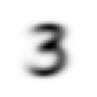

In [100]:
mean3 = stacked_threes.mean(0)
show_image(mean3);

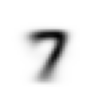

In [101]:
mean7 = stacked_sevens.mean(0)
show_image(mean7);

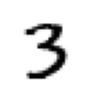

In [102]:
a_3 = stacked_threes[1]
show_image(a_3);

# Calculating the distance (loss)

### Why you can't use pixel by pixel mean
Pixel by Pixel difference when summed / mean will lose the individual pixel by pixel meaning  because the nature of summing / meaning will allow opposites (negative differences in on pixel and positive differences in another to cancel each other out)

### Absolute value of differences => L1 Norm = Mean absolute difference.
abs = turn negative to postive, this keeps the meaning of the difference because the cancellations from negative and postive numbers do not happen. the number is positive so the a big difference in the postive direct means a big diviation
### square of differences = root mean squared error (RMSE) = l2 norm.
squreing has the same effect by turing numbers positive and amplifies large differences

Distance is about how far off something is not about in which direction is it off so turning numbers from negative (-10) to postive (10) will give you that result.

### Used in regression (L1 and MSE)
predicting continuous values lke speed, price, temperature, (images in our case)

Pixelwise comparision because a_3 and mean3 are tensors

In [103]:
dist_3_abs = (a_3 - mean3).abs().mean()
dist_3_sqr = ((a_3 - mean3)**2).mean().sqrt()
dist_3_abs,dist_3_sqr

(tensor(0.1114), tensor(0.2021))

In [104]:
dist_7_abs = (a_3 - mean7).abs().mean()
dist_7_sqr = ((a_3 - mean7)**2).mean().sqrt()
dist_7_abs,dist_7_sqr

(tensor(0.1586), tensor(0.3021))

Pytorch built in loss function

In [105]:
F.l1_loss(a_3.float(),mean7), F.mse_loss(a_3,mean7).sqrt()

(tensor(0.1586), tensor(0.3021))

# Python tricks when using tensor or array (numpy)

In [106]:
data = [[1,2,3],[4,5,6]]
arr = array (data)
tns = tensor(data)


In [107]:
array([[1, 2, 3],
       [4, 5, 6]])

array([[1, 2, 3],
       [4, 5, 6]])

In [108]:
tensor([[1, 2, 3],
        [4, 5, 6]])

tensor([[1, 2, 3],
        [4, 5, 6]])

In [109]:
tns[1]


tensor([4, 5, 6])

In [110]:
tns[:1]

tensor([[1, 2, 3]])

select index 1 of the tensor (row) then select index 0 to but not including 2 (0,1)

In [111]:
tns[1,0:2]

tensor([4, 5])

use standard operations that applies to the whole tensor

In [112]:
tns + 6

tensor([[ 7,  8,  9],
        [10, 11, 12]])

# Validation Set

In [113]:
# Create the tensor for each image
valid_3_tens = torch.stack([tensor(Image.open(o)) for o in (path/'valid'/'3').ls()])
# Stack those images
valid_3_tens = valid_3_tens.float()/255

valid_7_tens = torch.stack([tensor(Image.open(o)) for o in (path/'valid'/'7').ls()])
valid_7_tens = valid_7_tens.float()/255

valid_3_tens.shape, valid_7_tens.shape

(torch.Size([1010, 28, 28]), torch.Size([1028, 28, 28]))

# Define the distance (loss) function

In [114]:
# mean((-1, -2)) is a pytorch to mean the last -1 and second last -2 dimensions e.g. [1010,28,28] the actual image pixels are mean
# this is flexible for all 2d images because the last two dimeinsion represent the image
# a-b allows pytorch to use broadcasting where the smaller tensor will have a virtal matching tensor so that the tensor arithmetic can happen
# because we mean((-1,-2)) the new dimensions added on do affect the desired result, ensures the calculation itself stays focused only on pixels.
def mnist_distance(a,b): return (a-b).abs().mean((-1,-2))
mnist_distance(a_3, mean3)

tensor(0.1114)

In [115]:
valid_3_dist = mnist_distance(valid_3_tens, mean3)
valid_3_dist, valid_3_dist.shape

(tensor([0.1634, 0.1145, 0.1363,  ..., 0.1105, 0.1111, 0.1640]),
 torch.Size([1010]))

In [116]:
(valid_3_tens-mean3).shape

torch.Size([1010, 28, 28])

In [117]:
# is_3 calculates distance of our 'perfect' 3 and compares it to 'perfect' 7 if the distance is small then it gravitates towards 3
# this is ofcourse only useful for comparing 3 and 7 and doesn't capture shapes that are not 3 or 7
def is_3(x): return mnist_distance(x,mean3) < mnist_distance(x,mean7)

In [118]:
is_3(a_3), is_3(a_3).float()

(tensor(True), tensor(1.))

In [119]:
is_3(valid_3_tens)

tensor([True, True, True,  ..., True, True, True])

In [120]:
accuracy_3s =      is_3(valid_3_tens).float() .mean()
accuracy_7s = (1 - is_3(valid_7_tens).float()).mean()

accuracy_3s,accuracy_7s,(accuracy_3s+accuracy_7s)/2

(tensor(0.9168), tensor(0.9854), tensor(0.9511))

# Stochastic Gradient Descent (SGD)
Instead of computing the gradient using your entire dataset at once (which is slow and memory-heavy), SGD picks a random subset of data, computes the loss & gradients for just that subset, and immediately updates the weights. This happens repeatedly until the model converges.

## thoughts and notes
Images, words, etc can be represented as data, you can use this data and plot it on a graph the graph is purely there as a visual representation on what we are trying to achive, which is training our model to out that passes through the data points such that we capture the underlying pattern.
A differential loss function with the gradient (calculated through the deriviate) is used to direct our model towards the optimal answer (optimised by gradient descent).The paramters to the model are adjusted based on gradient descent which tells the direct to adjust the parameters then step slowly. this is possible through derivatives which tell us the rate of change at a given point on a graph. there is a learning rate and epochs (number of times we train the model on the full set of training data).

its important to capture the underlying pattern in the data rather than passing through the optimal path because the latter will overfit the data and will not bable to detect outliers or data it hasent seen very well.

In [121]:
# x is the image w is the weight
def pr_eight(x,w): return (x*w).sum()

## Steps create a machine learning classifer:
1. *Initialize* the weights.
1. For each image, use these weights to *predict* whether it appears to be a 3 or a 7.
1. Based on these predictions, calculate how good the model is (its *loss*).
1. Calculate the *gradient*, which measures for each weight, how changing that weight would change the loss
1. *Step* (that is, change) all the weights based on that calculation.
1. Go back to the step 2, and *repeat* the process.
1. Iterate until you decide to *stop* the training process (for instance, because the model is good enough or you don't want to wait any longer).

1. Weights initilized randomly at the start
2. Loss => small number is good larger number is bad
3. Step change weights by increasing them bit a bit or decreasing them bit a bit, use calculus to find the gradient
4. decide on the epoch the goal is to get a good level of accuracy, keep training until the accuracy starts to get worse

## calculating loss by taking small steps
f(x) = x² is just a loss function for example and the idea is we want to reach the ideal output of the loss function which in this case is 0 and we do that by adjusting the paramters x
x² ideal loss is 0 mathematically but not ideal for machine learning.

By adjusting the values of x slowly we can slowly reach the goal of getting from one point to the bottom of the curve.

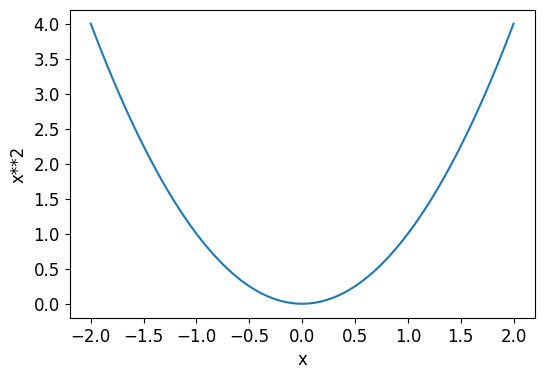

In [122]:
def f(x): return x**2
plot_function(f, 'x', 'x**2')

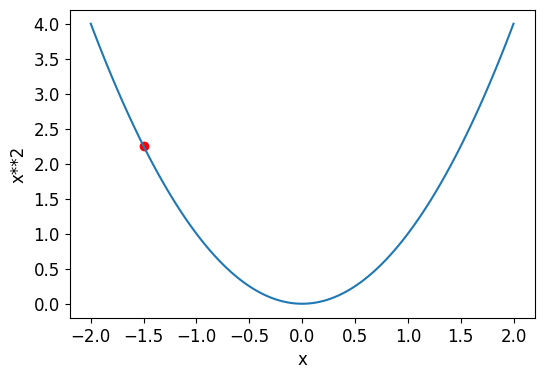

In [123]:
# By adjusting the paramters a and b we can get to the lower point of the slop
plot_function(f, 'x', 'x**2')
x = -1.5
y = -1.5
plt.scatter(y, f(x), color='red');

# Gradiant Descent

To understand first calculate the Gradient descent we need to understand derivative

## Average Rate of change (AROC)
The average rate of change captures how much the output changes as we change the input over an interval

Secant line is the rate of change at two points (the average rate of change)
tangent line is the instantanious rate of change at one point (if you nudge x how much does y change)

think of the tangent line as shrinking the internval to 0 and the secant line as having an interval between x and y the tangent line can tell us about the rate of change of the secant line

The secant slope changes as you move or shrink the interval.
The tangent slope (first derivative) can tells you how fast that secant slope is changing at any given point.
In fact, the second derivative  measures how fast the tangent slope itself is changing → it tells you whether the curve is bending upward or downward (concavity).

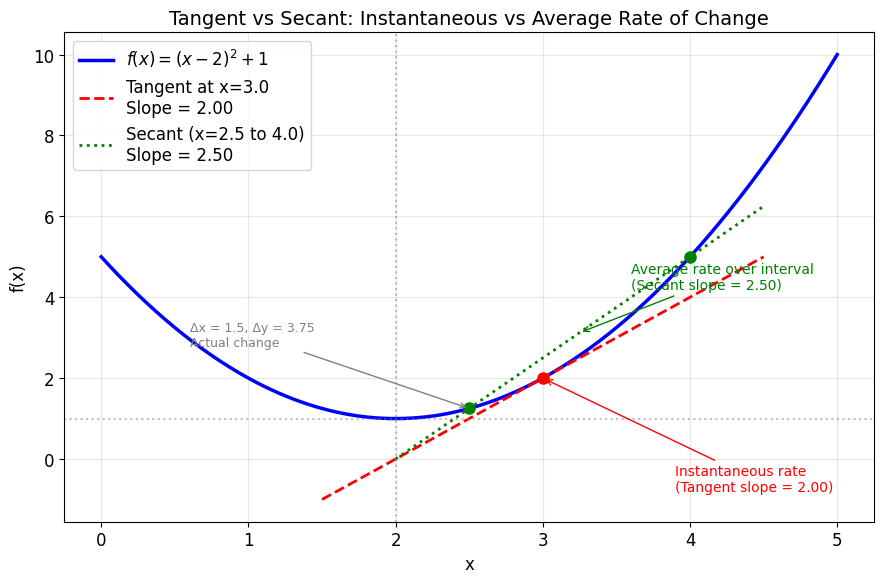

In [124]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Function & derivative
def f(x): return (x - 2)**2 + 1
def df(x): return 2 * (x - 2)

# Curve data
x = np.linspace(0, 5, 400)
y = f(x)

# Tangent point (instantaneous rate of change)
x_tan = 3.0
y_tan = f(x_tan)
slope_tan = df(x_tan)

# Secant points (average rate of change over an interval)
x1, x2 = 2.5, 4.0
y1, y2 = f(x1), f(x2)
slope_sec = (y2 - y1) / (x2 - x1)

# Line equations
x_tan_line = np.linspace(x_tan - 1.5, x_tan + 1.5, 100)
y_tan_line = slope_tan * (x_tan_line - x_tan) + y_tan

x_sec_line = np.linspace(x1 - 0.5, x2 + 0.5, 100)
y_sec_line = slope_sec * (x_sec_line - x1) + y1

# ================= PLOT =================
plt.figure(figsize=(9, 6))

# Curve
plt.plot(x, y, label=r'$f(x) = (x-2)^2 + 1$', color='blue', linewidth=2.5)

# Tangent line
plt.plot(x_tan_line, y_tan_line, label=f'Tangent at x={x_tan}\nSlope = {slope_tan:.2f}', 
         color='red', linestyle='--', linewidth=2)
plt.plot(x_tan, y_tan, 'ro', markersize=8)

# Secant line
plt.plot(x_sec_line, y_sec_line, label=f'Secant (x={x1} to {x2})\nSlope = {slope_sec:.2f}', 
         color='green', linestyle=':', linewidth=2)
plt.plot([x1, x2], [y1, y2], 'go', markersize=8)

# Annotations
plt.annotate(f'Instantaneous rate\n(Tangent slope = {slope_tan:.2f})', 
             xy=(x_tan, y_tan), xytext=(x_tan+0.9, y_tan-2.8),
             arrowprops=dict(arrowstyle='->', color='red'), fontsize=10, color='red')

plt.annotate(f'Average rate over interval\n(Secant slope = {slope_sec:.2f})', 
             xy=((x1+x2)/2, (y1+y2)/2), xytext=(3.6, 4.2),
             arrowprops=dict(arrowstyle='->', color='green'), fontsize=10, color='green')

# Show Δx & Δy for secant
dx = x2 - x1
dy = y2 - y1
plt.annotate(f'Δx = {dx:.1f}, Δy = {dy:.2f}\nActual change', 
             xy=(x1, y1), xytext=(0.6, 2.8),
             arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9, color='gray')

# Axes & styling
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.title('Tangent vs Secant: Instantaneous vs Average Rate of Change', fontsize=14)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.axhline(1, color='gray', linestyle=':', alpha=0.5)
plt.axvline(2, color='gray', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()


## Insantanious rate of change (IROC)
The instantaneous rate of change is the slope at a specific point

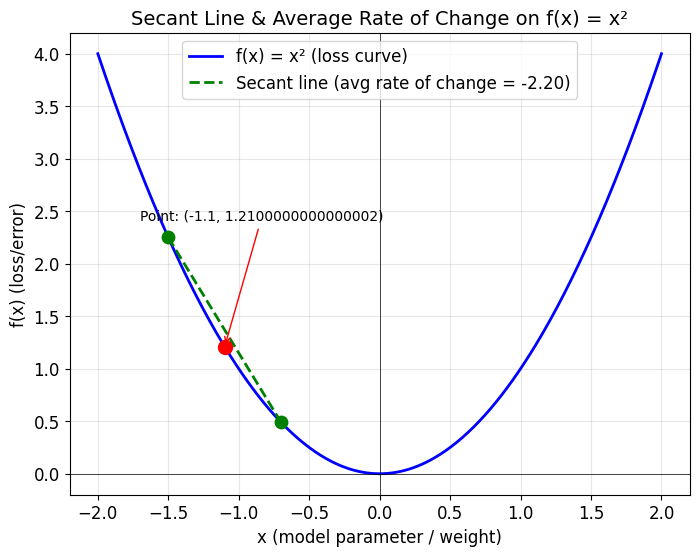

In [125]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the function
def f(x): return x**2

# 2. Generate smooth curve points
x_curve = np.linspace(-2, 2, 400)
y_curve = f(x_curve)

# 3. Plot the loss curve
plt.figure(figsize=(8, 6))
plt.plot(x_curve, y_curve, 'b-', linewidth=2, label='f(x) = x² (loss curve)')

# 4. Mark your point of interest
x_pt = -1.1
y_pt = f(x_pt)  # 1.21
plt.scatter([x_pt], [y_pt], color='red', s=100, zorder=5)
plt.annotate(f'Point: ({x_pt}, {y_pt})', xy=(x_pt, y_pt), 
             xytext=(x_pt-0.6, y_pt+1.2), fontsize=10,
             arrowprops=dict(arrowstyle='->', color='red'))

# 5. Draw a secant line between two points
x1, y1 = -1.5, f(-1.5)  # (−1.5, 2.25)
x2, y2 = -0.7, f(-0.7)  # (−0.7, 0.49)
plt.scatter([x1, x2], [y1, y2], color='green', s=80, zorder=5)
secant_slope = (y2 - y1) / (x2 - x1)
plt.plot([x1, x2], [y1, y2], 'g--', linewidth=2, 
         label=f'Secant line (avg rate of change = {secant_slope:.2f})')

# 6. Formatting
plt.xlabel('x (model parameter / weight)', fontsize=12)
plt.ylabel('f(x) (loss/error)', fontsize=12)
plt.title('Secant Line & Average Rate of Change on f(x) = x²', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.show()


## Derivative
Rate of change of y with respect to x of f 
Tangent line tells you how steep the curve is at one point
steep = slope => the rate of change when you move x (how does y change)
this is the gradiant (if i go this way how much would it chnage the loss)
The derivative calculates the rate of change at any given point which forms our gradiant value




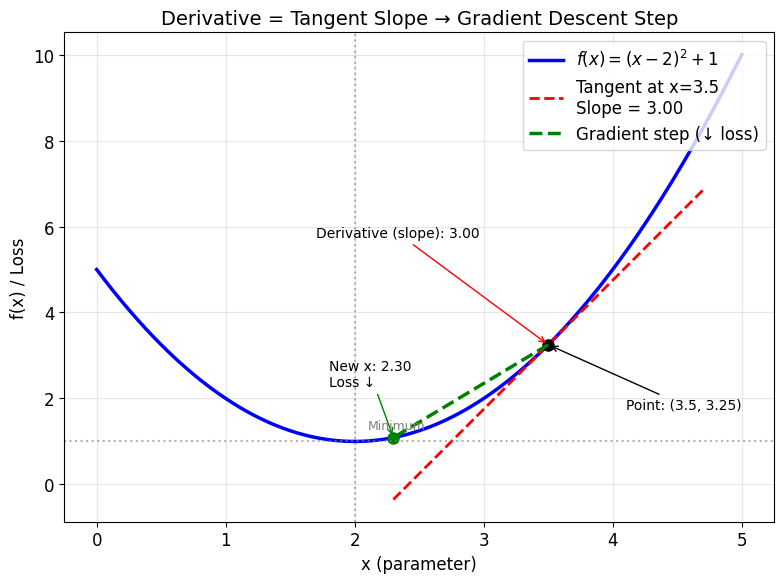

In [126]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the function (loss-like curve) and its derivative
def f(x):
    return (x - 2)**2 + 1          # Parabola with minimum at x=2

def df(x):
    return 2 * (x - 2)            # Derivative: rate of change at any x

# 2. Generate curve data
x = np.linspace(0, 5, 400)
y = f(x)

# 3. Pick a point to analyze
x0 = 3.5
y0 = f(x0)
slope = df(x0)                   # This is the derivative / gradient at x0

# 4. Tangent line equation: y = m*(x - x0) + y0
x_tangent = np.linspace(x0 - 1.2, x0 + 1.2, 100)
y_tangent = slope * (x_tangent - x0) + y0

# 5. Gradient descent step (how we'd update to reduce loss)
learning_rate = 0.4
x1 = x0 - learning_rate * slope  # Move opposite to gradient
y1 = f(x1)

# ================= PLOT =================
plt.figure(figsize=(8, 6))

# Curve
plt.plot(x, y, label=r'$f(x) = (x-2)^2 + 1$', color='blue', linewidth=2.5)

# Tangent line
plt.plot(x_tangent, y_tangent, label=f'Tangent at x={x0}\nSlope = {slope:.2f}', 
         color='red', linestyle='--', linewidth=2)

# Point on curve
plt.plot(x0, y0, 'ko', markersize=8)

# Gradient step
plt.plot([x0, x1], [y0, y1], 'g--', linewidth=2.5, label='Gradient step (↓ loss)')
plt.plot(x1, y1, 'go', markersize=8)

# Annotations
plt.annotate(f'Point: ({x0}, {y0:.2f})', xy=(x0, y0), xytext=(x0+0.6, y0-1.5),
             arrowprops=dict(arrowstyle='->', color='black'), fontsize=10)

plt.annotate(f'Derivative (slope): {slope:.2f}', xy=(x0, y0), xytext=(x0-1.8, y0+2.5),
             arrowprops=dict(arrowstyle='->', color='red'), fontsize=10)

plt.annotate(f'New x: {x1:.2f}\nLoss ↓', xy=(x1, y1), xytext=(x1-0.5, y1+1.2),
             arrowprops=dict(arrowstyle='->', color='green'), fontsize=10)

# Axes & styling
plt.xlabel('x (parameter)', fontsize=12)
plt.ylabel('f(x) / Loss', fontsize=12)
plt.title('Derivative = Tangent Slope → Gradient Descent Step', fontsize=14)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Mark the true minimum
plt.axhline(1, color='gray', linestyle=':', alpha=0.6)
plt.axvline(2, color='gray', linestyle=':', alpha=0.6)
plt.text(2.1, 1.3, 'Minimum', fontsize=9, color='gray')

plt.tight_layout()
plt.show()


The Derivative will tell us the rate of change at some point (x) but to get the optimal rate more is needed.

## The Derivate in Python

In [127]:
# f => f(x) = x^2, defined earlier
xt = tensor(3.).requires_grad_()
yt = f(xt)
yt

tensor(2., grad_fn=<AddBackward0>)

In [128]:
# backwards pass - name for calculating the derivative at each layer
yt.backward()
xt.grad

tensor(2.)


xt is a tensor and requires_grad_() marks it as needed gradiants
yt is the loss function and uses xt in its calculation (forward pass)
yt.Backwards will calculate  the gradiatns for xt and its stored in xt.grad 

In [129]:
xt = tensor([3.,4.,10.]).requires_grad_()
print (xt)

def f(x): return (x**2).sum()

yt = f(xt)
print (yt)

yt.backward()
xt.grad

tensor([ 3.,  4., 10.], requires_grad=True)
tensor(125., grad_fn=<SumBackward0>)


tensor([ 6.,  8., 20.])

## Learning rate
increments to the weight by stepping in the opposite direction of the gradient this allows us to follow the slope by going in the postivite direction when the slop is negative and negative when the slope is positive the goal is to minimise loss.

learning rate can be any value but generally 0.1 or less is used

# SDG example 2



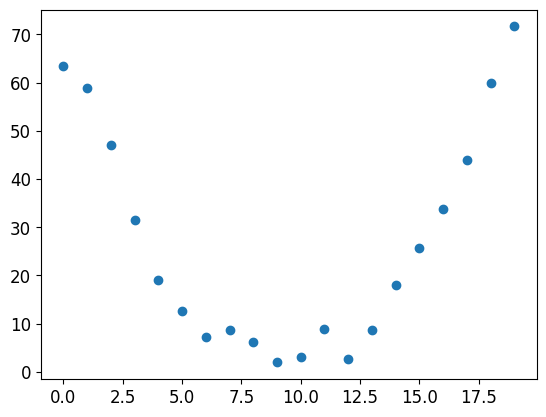

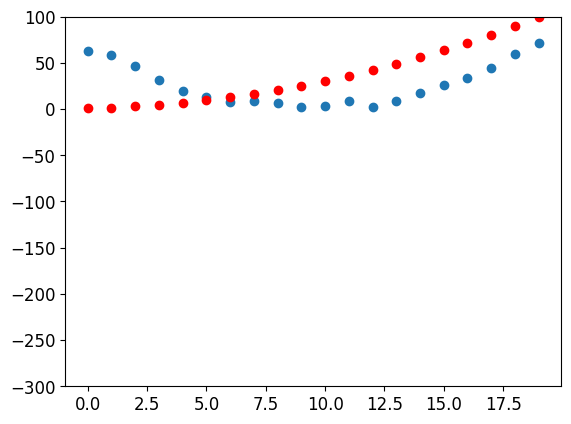

In [130]:
# random values for a rollercoaster speed data the 'regression' its the target our model wants to go towards. 
time = torch.arange(0,20).float(); time
speed = torch.randn(20)*3 + 0.75*(time-9.5)**2 + 1
plt.scatter(time,speed);

# our prediction function
def f(t, params):
    a,b,c = params
    return a*(t**2) + (b*t) + c

# our loss function using mse (squre root rule thingy)
def mse(preds, targets): return ((preds-targets)**2).mean()

# init parameters and track gradients
params = torch.randn(3).requires_grad_()
orig_params = params.clone()
params

# make a prediction (foward pass)
preds = f(time, params)

# show the predictions for the first run
def show_preds(preds, ax=None):
    if ax is None: ax=plt.subplots()[1]
    ax.scatter(time, speed)
    ax.scatter(time, to_np(preds), color='red')
    ax.set_ylim(-300,100)

show_preds(preds)



In [131]:
# calc the loss
loss = mse(preds, speed)

# calc the gradients from the loss (backwards pass) and updates the gradiantes to params
loss.backward()
print(params.grad)

# adjust the params based to fit between 0 and 1
print (params.grad * 1e-5)

print (params)

tensor([7735.3750,  510.7076,   18.9219])
tensor([0.0774, 0.0051, 0.0002])
tensor([0.2459, 0.5053, 0.9134], requires_grad=True)


In [132]:
# Step the weights
lr = 1e-5

# direclty modify the parameters (a,b,c) with the learning rate use -= to get opposite direction
params.data -= lr * params.grad.data
params.grad = None

In [133]:
# get new predictions (foward pass)
preds = f(time,params)

# calc the loss
mse(preds, speed)

tensor(716.1518, grad_fn=<MeanBackward0>)

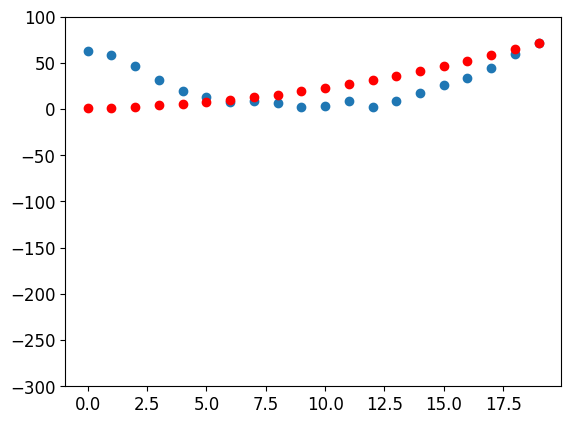

In [134]:
# compare results
show_preds(preds)

In [135]:
# repeat a few times
def apply_step(params, prn=True):
    preds = f(time, params)
    loss = mse(preds, speed)
    loss.backward()
    params.data -= lr * params.grad.data
    # this is needed because pythroch accumilates gradiants
    params.grad = None
    if prn: print(loss.item())
    return preds

In [136]:
for i in range(10): apply_step(params)

716.1517944335938
634.5519409179688
619.1072387695312
616.18115234375
615.6239013671875
615.5150146484375
615.4910278320312
615.4828491210938
615.4779052734375
615.4735107421875


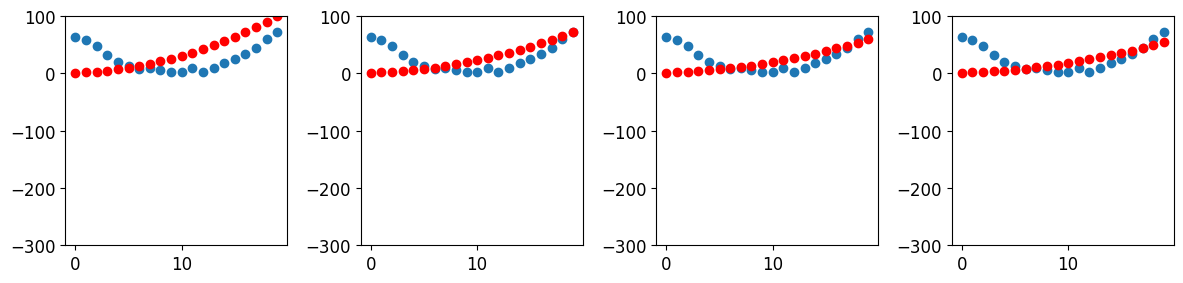

In [137]:
# sample 
params = orig_params.detach().requires_grad_()
_,axs = plt.subplots(1,4,figsize=(12,3))
for ax in axs: show_preds(apply_step(params, False), ax)
plt.tight_layout()

## Note on backwards pass
the derivative is calculated on the paramters the combination of the mean and the chain rule the gradient automatically influnces all points

# SDG Example 3

In [138]:
# Data prep. X is our input data (the images)
# View changes the shape of the data into something a neural network can use.
# torch cat will stack two tensors together. the -1 means that pytorch should figure out what to do with it.
# the view function changes the shape of a tensor without changing its data
# stack_threes and stack_sevens are tensors of the same size, but the dimension we stack on (batch) doesn't need to be the same.

# torch.cat combines the data set into one along the batch size dimension [b, h, w]
# view then changes the shape of the tensor to 2d tensor [total_images, h, w] => [total_images, hxw] each row is a flatten image, each column one position across all the images
train_x = torch.cat([stacked_threes, stacked_sevens]).view(-1, 28*28)
train_x

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [139]:
# label 3s (1) and 7s (0)
# threes and sevens are the orginal images collections
# train_y is the label of each image, train_x is the data (input)
train_y = tensor([1]*len(threes) + [0]*len(sevens)).unsqueeze(1)
train_x.shape,train_y.shape

(torch.Size([12396, 784]), torch.Size([12396, 1]))

In [140]:
dset = list(zip(train_x,train_y))
x,y = dset[0]
print(x.shape,y)

# Validation set
# Zip pairs the images with their labels
valid_x = torch.cat([valid_3_tens, valid_7_tens]).view(-1, 28*28)
valid_y = tensor([1]*len(valid_3_tens) + [0]*len(valid_7_tens)).unsqueeze(1)
valid_dset = list(zip(valid_x,valid_y))

torch.Size([784]) tensor([1])


In [141]:
# Step 1: Initialize the weights and bias
def init_params(size, std=1.0): return (torch.randn(size)*std).requires_grad_()
bias = init_params(1)
weights = init_params((28*28,1)) # because of the dot product weghts nees 784 rows and 1 column [784,1] to match with [784,1] from train_x
print(weights)

tensor([[ 0.7831],
        [-0.7242],
        [-1.4133],
        [-0.3707],
        [ 0.2631],
        [ 0.5066],
        [ 0.6554],
        [ 0.8003],
        [ 1.8890],
        [ 0.2822],
        [ 0.0370],
        [ 1.8072],
        [ 0.3590],
        [ 0.4349],
        [ 1.6250],
        [-0.1016],
        [ 1.2011],
        [ 0.2438],
        [-2.4870],
        [ 1.1063],
        [ 0.5106],
        [-1.0290],
        [-0.3153],
        [ 0.8649],
        [-0.7003],
        [ 0.6223],
        [-1.0504],
        [-1.3519],
        [ 1.0266],
        [-0.3877],
        [-0.4631],
        [-0.0461],
        [-0.4254],
        [ 0.0554],
        [ 0.5681],
        [-0.2995],
        [-1.1212],
        [-0.7190],
        [ 0.5908],
        [-2.3821],
        [ 0.5449],
        [-0.7775],
        [-1.3098],
        [ 1.4623],
        [ 2.0723],
        [-1.4677],
        [-2.1611],
        [-1.5601],
        [ 0.5937],
        [ 0.2239],
        [ 1.0692],
        [ 0.4514],
        [ 1.

In [142]:
# Step 2: make a prediction, sum is required for the dot product.
(train_x[0]*weights.T).sum() + bias


tensor([7.5051], grad_fn=<AddBackward0>)

In [143]:
# Make many predictions use matrix multiplication
def linear1(xb): return xb@weights + bias
preds = linear1(train_x)
preds

tensor([[ 7.5051],
        [13.4154],
        [10.2470],
        ...,
        [ 1.2524],
        [-6.0293],
        [ 2.1562]], grad_fn=<AddBackward0>)

In [144]:
# Calculate the loss
corrects = (preds>0.0).float() == train_y
print(corrects)
corrects.float().mean().item()

tensor([[ True],
        [ True],
        [ True],
        ...,
        [False],
        [ True],
        [False]])


0.7136979699134827

In [145]:
# Testing what change in accurace is for a small change (telling pytorch to not track the gradient)
with torch.no_grad(): weights[0] *= 1.0001
preds = linear1(train_x)
((preds>0.0).float() == train_y).float().mean().item()

0.7136979699134827

### Loss function
Dont use accuracy because the only way to flip a prediction is to cross the threadhold of 0.5 so it will take a lot of small changes to flip predictions.
Accuracy is 1 = 3s, 0 = 7s so we need a loss function that can punish small changes in prediction confidence e.g. from 0.8 to 0.6.

accuracty stays flat the loss calculated losses the small increaments in change because 1 or 0 when its plotted it would resemble a stair case with values of 0 or 1.

### My reasoning

The loss function provides a score (x) to allow use to calculate the gradiant and if we use accuracy then its either 1 or 0 because the value has to be rounded to match the accuracy value of 1 or 0 which loses the closeness the prediection was from 1 or 0. we should instead use the raw prediction value - the target then MSE or L1

targets is 1 = 3s or 0 = 7s thats the label we can't use the accuracy as the loss function because it will take a lot of steps to flip a prediction from 3s to 7s. (you have to reach pass 0.5)

What we should do is use the prediction confidence e.g. its 0.8 = closer to 1 = 3s or 0.2 = 7s.
Then subtract the target from the predection then use MSE or L1 to get the loss.
This would punish predictions that are far away from the target and reward predictions that are closer to the target.


In [146]:
trgts  = tensor([1,0,1])
prds   = tensor([0.9, 0.4, 0.2])
def mnist_loss(predictions, targets):
    return torch.where(targets==1, 1-predictions, predictions).mean()

torch.where(trgts==1, 1-prds, prds)
mnist_loss(prds,trgts)
mnist_loss(tensor([0.9, 0.4, 0.8]),trgts)

tensor(0.2333)

## Sigmoid
overt the range of -inf to inf the sigmoid function will output a value between 0 and 1.

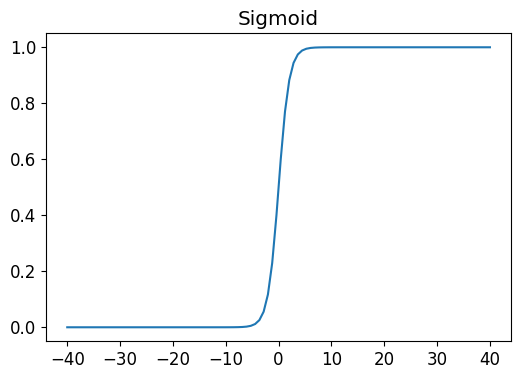

In [147]:
def sigmoid(x): return 1/(1+torch.exp(-x))

plot_function(torch.sigmoid, title='Sigmoid', min=-40, max=40)

In [148]:
# Use the sigmoid function to make sure our predictions are between 0 and 1.
def mnist_loss(predictions, targets):
    predictions = predictions.sigmoid()
    return torch.where(targets==1, 1-predictions, predictions).mean()

## Mini batch
Mini batch is a small sample of data from the training set. We can use this to train our model in batches instead of all at once. this will help us to avoid overfitting and underfitting. batches are determined randomly by shuffling the data set at the start of each epoch. 

over fitting happens when you try to calculate the loss for each training example, which is also computationally expensive. what calcuating the loss for each training sample does is gives information on how to improve accuracy for that particular training sample.

In [149]:
# randomly initialise weights and bias.
weights = init_params((28*28,1))
bias = init_params(1) # bias used to tilt answer towards an outcome and is important for our model to learn.

# randomised mini batches of data from the training set.
dl = DataLoader(dset, batch_size=256) # get 256 random images from dset
xb,yb = first(dl) # xb is the data, yb is the labels
print(xb.shape,yb.shape)

# randomise mini batches of data for the training set.
valid_dl = DataLoader(valid_dset, batch_size=256) # get 256 random images from valid_dset


torch.Size([256, 784]) torch.Size([256, 1])


In [150]:
# mini batch of size 4
batch = train_x[:4] # train x is [total_images, 784] (28x28 = 784) and get the first 4 rows so the shape is [4,784]
batch.shape

torch.Size([4, 784])

In [151]:
preds = linear1(batch) # matrix multiply to get the predictions (forwards pass)
preds

tensor([[0.7276],
        [1.3124],
        [1.0601],
        [6.9683]], grad_fn=<AddBackward0>)

In [152]:
loss = mnist_loss(preds, train_y[:4]) # loss calc
loss

tensor(0.1990, grad_fn=<MeanBackward0>)

In [153]:
# calculate the gradiants (backwards pass)
loss.backward()
weights.grad.shape,weights.grad.mean(),bias.grad

(torch.Size([784, 1]), tensor(-0.0207), tensor([-0.1447]))

In [154]:
# gradiant function
def calc_grad(xb, yb, model):
    preds = model(xb)
    loss = mnist_loss(preds, yb)
    loss.backward()

# test
calc_grad(batch, train_y[:4], linear1)
weights.grad.mean(),bias.grad

(tensor(-0.0414), tensor([-0.2894]))

In [155]:
# rset back pytorch operations that end in _ modify their objects in place.
weights.grad.zero_()
bias.grad.zero_();

In [156]:
# Imporant to not let pytorch also track the step (where we update the weights) as it will be tracked and added to the computational graph.
# This is why we need to use .data
def train_epoch(model, lr, params):
    for xb,yb in dl:
        calc_grad(xb, yb, model)
        for p in params:
            p.data -= p.grad*lr
            p.grad.zero_()

In [157]:
(preds>0.0).float() == train_y[:4]

tensor([[True],
        [True],
        [True],
        [True]])

In [158]:
# Accuracy not the loss function
def batch_accuracy(xb, yb):
    preds = xb.sigmoid()
    correct = (preds>0.5) == yb
    return correct.float().mean()

In [159]:
def validate_epoch(model):
    accs = [batch_accuracy(model(xb), yb) for xb,yb in valid_dl]
    return round(torch.stack(accs).mean().item(), 4)

In [160]:
# train
validate_epoch(linear1)

0.6043

In [161]:
lr = 1.
params = weights,bias
train_epoch(linear1, lr, params)
validate_epoch(linear1)

0.7417

In [162]:
for i in range(20):
    train_epoch(linear1, lr, params)
    print(validate_epoch(linear1), end=' ')

0.8843 0.9272 0.9462 0.954 0.9584 0.9613 0.9633 0.9643 0.9667 0.9677 0.9696 0.9691 0.9701 0.9701 0.9701 0.9711 0.9721 0.9721 0.9721 0.974 

# Pytorch 
Has the Optionmise for us that handles
- Init weights and bias
- Gradiant tracking on weights and bias
- Parameter registraion
- Forward pass

In [163]:
linear_model = nn.Linear(28*28,1)

### BasicOptim 
does two things
- group the step so we can call .step
- groups the zero gradiant into zero_grad so we can just call .zero_grad

zero grad is needed to prevent the gradiant from accumulating over the batches
Each batch is independent: The next batch contains different images, so its gradient points in a completely different direction. We want to act on that specific signal before moving forward.
Clearing gradients keeps steps clean: If we didn't clear them, the next batch's gradient would get added to the previous one, mixing two different data signals into a single update.

In [164]:
class BasicOptim:
    def __init__(self,params,lr): self.params,self.lr = list(params),lr

    def step(self, *args, **kwargs):
        for p in self.params: p.data -= p.grad.data * self.lr

    def zero_grad(self, *args, **kwargs):
        for p in self.params: p.grad = None

In [165]:
opt = BasicOptim(linear_model.parameters(), lr)

In [166]:
def train_epoch(model):
    for xb,yb in dl:
        calc_grad(xb, yb, model)
        opt.step()
        opt.zero_grad()

In [167]:
validate_epoch(linear_model)

0.6052

In [168]:
def train_model(model, epochs):
    for i in range(epochs):
        train_epoch(model)
        print(validate_epoch(model), end=' ')

In [169]:
train_model(linear_model, 20)

0.4932 0.8467 0.8447 0.9145 0.9346 0.9482 0.9551 0.9624 0.9658 0.9673 0.9687 0.9712 0.9736 0.9751 0.9761 0.9761 0.9775 0.978 0.978 0.9785 

### Fast AI optimiserzer"""
which does it all for you just provide the model and the number of epochs

In [170]:
linear_model = nn.Linear(28*28,1)
opt = SGD(linear_model.parameters(), lr)
train_model(linear_model, 20)

0.4932 0.7773 0.8545 0.9165 0.9355 0.9487 0.9565 0.9643 0.9658 0.9678 0.9697 0.9717 0.9736 0.9746 0.9761 0.9765 0.9775 0.978 0.9785 0.9785 

### Fast AI AI Learner"""

In [171]:
dls = DataLoaders(dl, valid_dl)
learn = Learner(dls, nn.Linear(28*28,1), opt_func=SGD,
                loss_func=mnist_loss, metrics=batch_accuracy)
learn.fit(10, lr=lr)

epoch,train_loss,valid_loss,batch_accuracy,time
0,0.637455,0.503500,0.495584,00:00
1,0.526789,0.218254,0.805692,00:00
2,0.194043,0.174269,0.843474,00:00
3,0.085033,0.104182,0.914132,00:00
4,0.044833,0.076413,0.935231,00:00
5,0.029124,0.061368,0.948479,00:00
6,0.022664,0.051985,0.955839,00:00
7,0.019789,0.045746,0.963690,00:00
8,0.018326,0.041356,0.966143,00:00
9,0.017446,0.038113,0.968597,00:00


# Nonlinearity
Making things nonlinear is to allow the predictions to bend and form more complex shapes. We can do this by adding a non-linearity after our linear function.
"""

your ReLu and Sigmoid and Tanh and softmax

How complex shapes form

Input	            After Layer 1 (Linear)	After ReLU (Bend)	After Layer 2 (Linear)
[-2, -1, 0, 1, 2]	[-4, -2, 0, 2, 4]	    [0, 0, 0, 2, 4]	    [1, -3, -7, 5, 9]

if you plot relu allowed shapes to be more complex than linear (straight line)

non linear is needed because real data isn't a straight line

this is backed by the Universal Approximation Theorem (UAT) which says that a neural network with one hidden layer and arbitrary activation function can approximate any continuous function to arbitrary accuracy.

### Layers in a Neural Network
1. Layer one has its own weights (nn.Linear() will assign random weights and track its own) relu or other normaliztion functions is used to turn in non linear
2. the resulting vector is passed to the next layer layer 2
3. Layer 2 has its own weights and does the same thing as layer 1
3. this continues to as manylayers as you want
4. the final layer is the output layer which has its own weights and outputs a vector of predictions

each layer does a different task e.g. layer 1 could be for recognizing shapes layer 2 could get the outlines layer 3 could zero in on the target shapes etc.

### Nonlinear Activation Functions
Linear → ReLU → Linear is the minimal architecture that UAT applies to
"Make the lines smaller" = add more hidden neurons → create more kinks/bends → approximate finer details
UAT guarantees that with enough hidden units, this setup can approximate any continuous function to arbitrary accuracy

### Weights
With the correct weights (found through our training) we can approximate just about anything.

### Activiations and Parameters Definition

Activations = numbers computed in the forward pass from data × parameters (they flow through the network as intermediate outputs)
Parameters = learnable weights/biases that get updated using gradients (gradients tell them how to change; the optimizer applies it)
That's the complete training cycle:

Data + Parameters → Activations (forward) → Loss → Gradients → Parameter Update (backward)


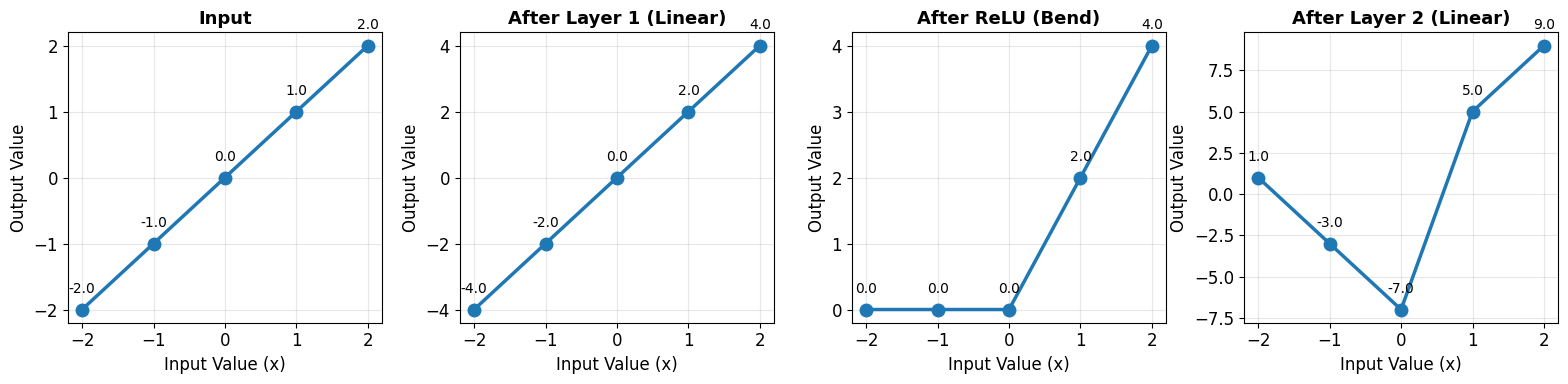

In [172]:
import matplotlib.pyplot as plt
import numpy as np

# Your exact example data
x = np.array([-2, -1, 0, 1, 2])
after_lin1 = np.array([-4, -2, 0, 2, 4])
after_relu = np.maximum(0, after_lin1)  # [0, 0, 0, 2, 4]
after_lin2 = np.array([1, -3, -7, 5, 9])

# Create a 4-panel figure showing the transformation
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
titles = ['Input', 'After Layer 1 (Linear)', 'After ReLU (Bend)', 'After Layer 2 (Linear)']
data = [x, after_lin1, after_relu, after_lin2]

for ax, title, d in zip(axes, titles, data):
    ax.plot(x, d, 'o-', linewidth=2.5, markersize=9)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Input Value (x)')
    ax.set_ylabel('Output Value')
    ax.grid(True, alpha=0.3)
    
    # Annotate each point with its value
    for i, val in enumerate(d):
        ax.annotate(f'{val:.1f}', (x[i], val), textcoords="offset points", 
                    xytext=(0, 12), ha='center', fontsize=10)

plt.tight_layout()
plt.show()


In [173]:
def simple_net(xb): 
    res = xb@w1 + b1
    res = res.max(tensor(0.0)) # non linear
    res = res@w2 + b2
    return res

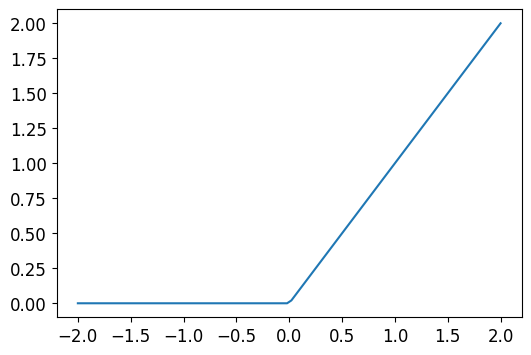

In [174]:
# relu just negatives to 0
plot_function(F.relu)

In [175]:
w1 = init_params((28*28,30))
b1 = init_params(30)
w2 = init_params((30,1))
b2 = init_params(1)

In [176]:
# Model setup (wieghts, bias, relu, gradient tracking)
simple_net = nn.Sequential(
    nn.Linear(28*28,30),
    nn.ReLU(),
    nn.Linear(30,1)
)

In [177]:
# create the learner and supply SDG, lossfunction and metircs
learn = Learner(dls, simple_net, opt_func=SGD,
                loss_func=mnist_loss, metrics=batch_accuracy)
learn.fit(40, 0.1)

epoch,train_loss,valid_loss,batch_accuracy,time
0,0.293125,0.415264,0.504416,00:00
1,0.141339,0.221927,0.813543,00:00
2,0.079207,0.112860,0.914132,00:00
3,0.052531,0.076529,0.942591,00:00
4,0.040057,0.059893,0.957311,00:00
5,0.033630,0.050557,0.964671,00:00
6,0.029906,0.044668,0.966634,00:00
7,0.027475,0.040640,0.967615,00:00
8,0.025719,0.037708,0.968106,00:00
9,0.024359,0.035475,0.970559,00:00


In [178]:
learn.recorder.values[-1][2]

0.982826292514801